# Pipeline — Give Me Some Credit

This notebook loads the dataset, fixes data types, builds a full scikit-learn pipeline with custom transformers, trains the model, and evaluates results. Every step in the pipeline is justified by what we found during EDA.

---
## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
%matplotlib inline

---
## 2. Load Data

In [4]:
df = pd.read_csv(r'..\data\cs-training.csv', index_col=0)
print('Shape:', df.shape)
df.head()

Shape: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.7661,45,2,0.8030,9120.0000,13,0,6,0,2.0000
2,0,0.9572,40,0,0.1219,2600.0000,4,0,0,0,1.0000
3,0,0.6582,38,1,0.0851,3042.0000,2,1,0,0,0.0000
4,0,0.2338,30,0,0.0360,3300.0000,5,0,0,0,0.0000
5,0,0.9072,49,1,0.0249,63588.0000,7,0,1,0,0.0000


In [ ]:
df[(df['NumberOfTimes90DaysLate'] > 0) & (df['NumberOfTime30-59DaysPastDueNotWorse'] == 0)]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
50,0,0.0001,70,0,0.2563,6900.0000,21,1,1,0,0.0000
69,0,0.0043,31,0,0.1114,2000.0000,6,1,0,0,2.0000
73,0,0.8277,56,0,0.3696,6793.0000,15,1,1,0,0.0000
96,0,0.2454,37,0,0.2884,6500.0000,11,1,1,1,0.0000
177,0,1.0000,69,0,0.0053,2255.0000,0,1,0,0,3.0000
...,...,...,...,...,...,...,...,...,...,...,...
149904,1,0.5522,55,0,0.3370,1800.0000,7,1,0,0,1.0000
149955,1,1.0000,46,0,170.3980,401.0000,3,2,0,0,2.0000
149963,0,1.0057,48,0,0.2489,2944.0000,4,3,0,0,1.0000
149969,1,0.9838,55,0,0.0641,4600.0000,2,1,0,0,6.0000


---
## 3. Data Type Fixes

Before anything else, fix the data types. The delinquency count columns and NumberOfDependents are stored as floats because of missing values, but they represent counts — they should be treated as such. We also confirm the target is integer.

In [5]:
print('Data types before fixing:')
print(df.dtypes)
print()
print('Missing values per column:')
print(df.isnull().sum())

Data types before fixing:
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

Missing values per column:
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines        

In [6]:
# These are count columns stored as float due to NaN presence
# We leave them as float64 here because the pipeline's imputer
# will fill NaNs first — after that they could be cast to int,
# but sklearn handles float counts fine. No conversion needed.

# What we DO fix: the target must be int, not float
df['SeriousDlqin2yrs'] = df['SeriousDlqin2yrs'].astype(int)

# age: should be int (no missing values, no decimals)
df['age'] = df['age'].astype(int)

print('Data types after fixing:')
print(df.dtypes)

Data types after fixing:
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object


---
## 4. Remove Known Data Errors

EDA identified specific rows that are clearly wrong and cannot be recovered by imputation:
- `age == 0`: logically impossible
- Sentinel values 96 and 98 in the delinquency columns: these appear in large counts and are not real delinquency counts

These are removed before the pipeline so the transformer does not have to deal with them.

In [7]:
print('Rows before cleaning:', len(df))

# Remove age == 0
df = df[df['age'] > 0]

# Remove sentinel values in delinquency columns
delinquency_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

for col in delinquency_cols:
    df = df[~df[col].isin([96, 98])]

# Remove exact duplicates
df = df.drop_duplicates()

print('Rows after cleaning:', len(df))
print('Rows removed:', 150000 - len(df))

Rows before cleaning: 150000
Rows after cleaning: 149165
Rows removed: 835


---
## 5. Train / Test Split

Split before building the pipeline. The pipeline will only ever be fitted on the training set.

In [8]:
TARGET = 'SeriousDlqin2yrs'

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # preserve class ratio in both splits
)

print('Training set size :', X_train.shape)
print('Test set size     :', X_test.shape)
print()
print('Target distribution in train:')
print(y_train.value_counts(normalize=True).round(4))

Training set size : (119332, 10)
Test set size     : (29833, 10)

Target distribution in train:
SeriousDlqin2yrs
0   0.9338
1   0.0662
Name: proportion, dtype: float64


---
## 6. Custom Transformers

Three custom transformers address problems that scikit-learn's built-in steps do not cover directly.

### 6.1 OutlierCapper

EDA showed that `RevolvingUtilizationOfUnsecuredLines` has values in the tens of thousands when it should be a ratio between 0 and 1. Other features also have extreme values beyond any realistic ceiling. This transformer caps each column at a percentile boundary computed from the training data.

In [9]:
class OutlierCapper(BaseEstimator, TransformerMixin):
    """
    Caps numerical features at a given lower and upper percentile.
    Boundaries are learned from training data only.
    """

    def __init__(self, lower_pct=0.01, upper_pct=0.99):
        self.lower_pct = lower_pct
        self.upper_pct = upper_pct

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.lower_bounds_ = X.quantile(self.lower_pct)
        self.upper_bounds_ = X.quantile(self.upper_pct)
        return self

    def transform(self, X, y=None):
        X = pd.DataFrame(X).copy()
        for col in X.columns:
            X[col] = X[col].clip(
                lower=self.lower_bounds_[col],
                upper=self.upper_bounds_[col]
            )
        return X.values

### 6.2 MissingFlagAdder

EDA and the chi-square test showed that the default rate differs between rows where `MonthlyIncome` and `NumberOfDependents` are missing vs present. This means the missingness carries information. This transformer adds a binary flag column for each column with missing values before imputation fills them in.

In [10]:
class MissingFlagAdder(BaseEstimator, TransformerMixin):
    """
    For each specified column, adds a binary indicator column
    (1 = value was missing, 0 = value was present).
    The original column is left unchanged for the imputer to fill.
    """

    def __init__(self, cols_to_flag=None):
        self.cols_to_flag = cols_to_flag

    def fit(self, X, y=None):
        # Nothing to learn — just check which columns to flag
        return self

    def transform(self, X, y=None):
        X = pd.DataFrame(X).copy()
        if self.cols_to_flag:
            for col in self.cols_to_flag:
                if col in X.columns:
                    X[str(col) + '_missing'] = X[col].isnull().astype(int)
        return X.values

### 6.3 SkewnessTransformer

EDA showed that several features have very high skewness scores. A log1p transformation compresses the long right tails and makes the distributions more symmetric. This helps linear models significantly. Tree-based models are not sensitive to this, but the transformation does not hurt them either.

In [11]:
class SkewnessTransformer(BaseEstimator, TransformerMixin):
    """
    Applies log1p transformation to columns whose skewness
    exceeds a given threshold, measured on the training data.
    Only applies to columns where all values are >= 0.
    """

    def __init__(self, threshold=1.0):
        self.threshold = threshold

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        skewness = X.skew()
        # Only flag columns where values are non-negative (log1p requires >= 0)
        non_negative = (X.min() >= 0)
        self.cols_to_transform_ = skewness[
            (skewness.abs() > self.threshold) & non_negative
        ].index.tolist()
        return self

    def transform(self, X, y=None):
        X = pd.DataFrame(X).copy()
        for col in self.cols_to_transform_:
            if col in X.columns:
                X[col] = np.log1p(X[col])
        return X.values

---
## 7. Define Column Groups

The `MissingFlagAdder` needs to know which columns to flag by name. We define this based on EDA findings.

In [12]:
# Columns confirmed to have predictive missingness from chi-square test
COLS_TO_FLAG = ['MonthlyIncome', 'NumberOfDependents']

print('Feature columns:', X_train.columns.tolist())
print()
print('Columns that will receive missing flags:', COLS_TO_FLAG)

Feature columns: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

Columns that will receive missing flags: ['MonthlyIncome', 'NumberOfDependents']


---
## 8. Build the Pipeline

The steps are ordered deliberately:

1. **MissingFlagAdder** — must run before imputation, otherwise the missing information is lost
2. **OutlierCapper** — run before imputation so extreme values do not skew the median
3. **SimpleImputer** — fills remaining NaNs with the median
4. **SkewnessTransformer** — log1p after imputation so there are no NaNs in the skewness calculation
5. **StandardScaler** — scale after all transformations are done
6. **Model** — the final estimator

In [13]:
def build_pipeline(model):
    return Pipeline([
        ('flag_missing',  MissingFlagAdder(cols_to_flag=COLS_TO_FLAG)),
        ('cap_outliers',  OutlierCapper(lower_pct=0.01, upper_pct=0.99)),
        ('impute',        SimpleImputer(strategy='median')),
        ('fix_skewness',  SkewnessTransformer(threshold=1.0)),
        ('scale',         StandardScaler()),
        ('model',         model)
    ])

print('Pipeline structure defined.')

Pipeline structure defined.


---
## 9. Train and Evaluate

We compare three models inside the same pipeline. Because the dataset is imbalanced (~93/7), we use `class_weight='balanced'` where available. The primary metric is AUC-ROC. We also report precision, recall, and F1 for both classes.

In [14]:
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    )
}

In [15]:
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    pipe = build_pipeline(model)

    # Cross-validation AUC on training set
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

    # Fit on full training set
    pipe.fit(X_train, y_train)

    # Predict on test set
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    test_auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        'pipeline':  pipe,
        'y_pred':    y_pred,
        'y_prob':    y_prob,
        'cv_auc':    cv_scores,
        'test_auc':  test_auc
    }

    print(f'{name}')
    print(f'  CV AUC  : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')
    print(f'  Test AUC: {test_auc:.4f}')
    print()

Logistic Regression
  CV AUC  : 0.8577 (+/- 0.0038)
  Test AUC: 0.8507

Random Forest
  CV AUC  : 0.8385 (+/- 0.0015)
  Test AUC: 0.8266

Gradient Boosting
  CV AUC  : 0.8639 (+/- 0.0038)
  Test AUC: 0.8573



---
## 10. Results

### 10.1 AUC Comparison

In [16]:
summary = pd.DataFrame({
    name: {
        'CV AUC Mean': res['cv_auc'].mean(),
        'CV AUC Std':  res['cv_auc'].std(),
        'Test AUC':    res['test_auc']
    }
    for name, res in results.items()
}).T

print(summary.round(4))

                     CV AUC Mean  CV AUC Std  Test AUC
Logistic Regression       0.8577      0.0038    0.8507
Random Forest             0.8385      0.0015    0.8266
Gradient Boosting         0.8639      0.0038    0.8573


### 10.2 ROC Curves

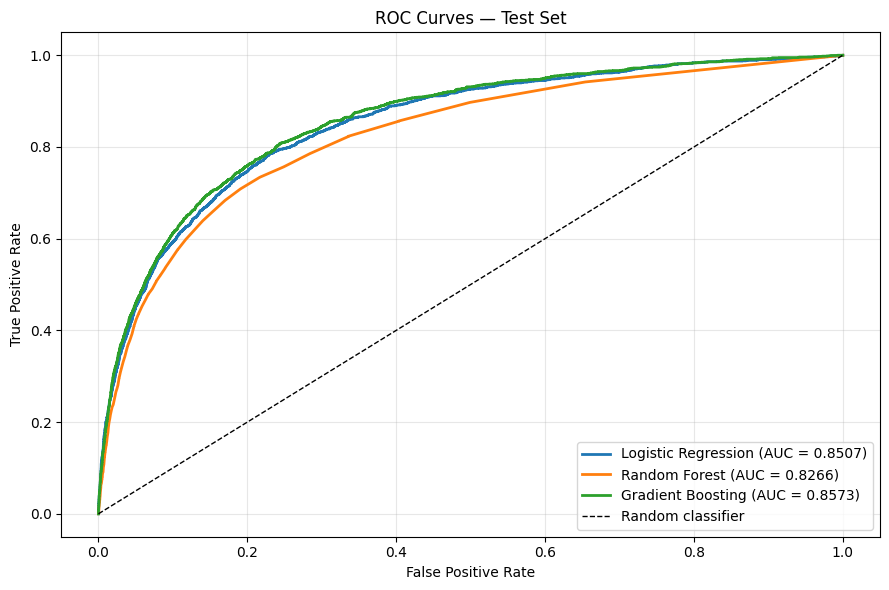

In [17]:
plt.figure(figsize=(9, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['test_auc']:.4f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Test Set')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 10.3 Precision-Recall Curves

With a 93/7 imbalance, the ROC curve can look optimistic. The precision-recall curve gives a more honest picture of performance on the minority class.

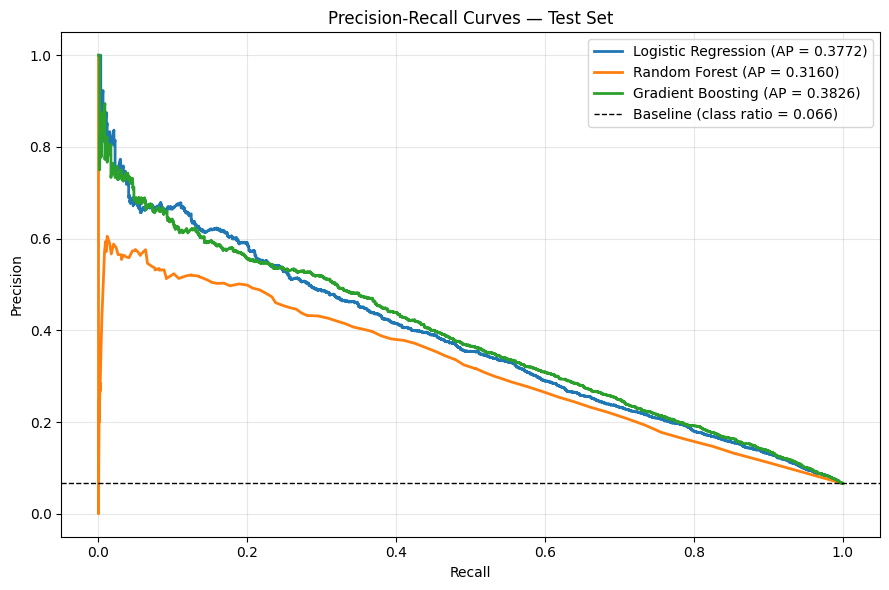

In [18]:
plt.figure(figsize=(9, 6))

for name, res in results.items():
    precision, recall, _ = precision_recall_curve(y_test, res['y_prob'])
    ap = average_precision_score(y_test, res['y_prob'])
    plt.plot(recall, precision, label=f"{name} (AP = {ap:.4f})", linewidth=2)

baseline = y_test.mean()
plt.axhline(y=baseline, color='k', linestyle='--', linewidth=1, label=f'Baseline (class ratio = {baseline:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — Test Set')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 10.4 Classification Reports

In [19]:
for name, res in results.items():
    print(f'--- {name} ---')
    print(classification_report(y_test, res['y_pred'], target_names=['No Default', 'Default']))
    print()

--- Logistic Regression ---
              precision    recall  f1-score   support

  No Default       0.98      0.81      0.89     27858
     Default       0.22      0.74      0.33      1975

    accuracy                           0.81     29833
   macro avg       0.60      0.77      0.61     29833
weighted avg       0.93      0.81      0.85     29833


--- Random Forest ---
              precision    recall  f1-score   support

  No Default       0.94      0.99      0.97     27858
     Default       0.51      0.14      0.22      1975

    accuracy                           0.93     29833
   macro avg       0.73      0.57      0.60     29833
weighted avg       0.91      0.93      0.92     29833


--- Gradient Boosting ---
              precision    recall  f1-score   support

  No Default       0.94      0.99      0.97     27858
     Default       0.57      0.18      0.28      1975

    accuracy                           0.94     29833
   macro avg       0.76      0.59      0.62     29

### 10.5 Confusion Matrices

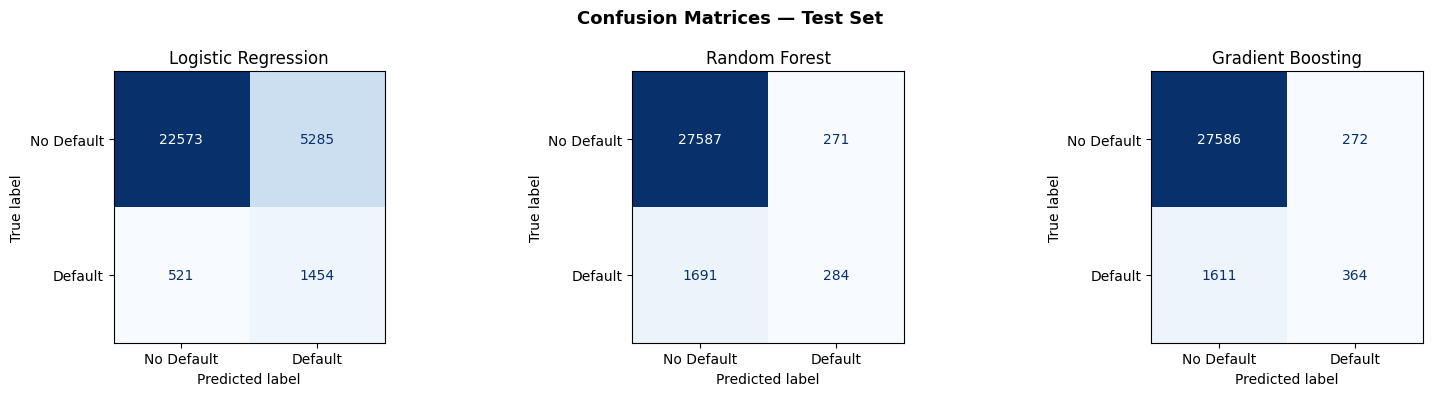

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.suptitle('Confusion Matrices — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 10.6 Feature Importance (Best Model)

For tree-based models we can extract feature importances. This tells us which features the model relied on most, and we can compare this to what EDA suggested.

In [21]:
# Use the best model by test AUC
best_name = max(results, key=lambda x: results[x]['test_auc'])
best_pipe = results[best_name]['pipeline']

print(f'Best model by test AUC: {best_name} ({results[best_name]["test_auc"]:.4f})')

Best model by test AUC: Gradient Boosting (0.8573)


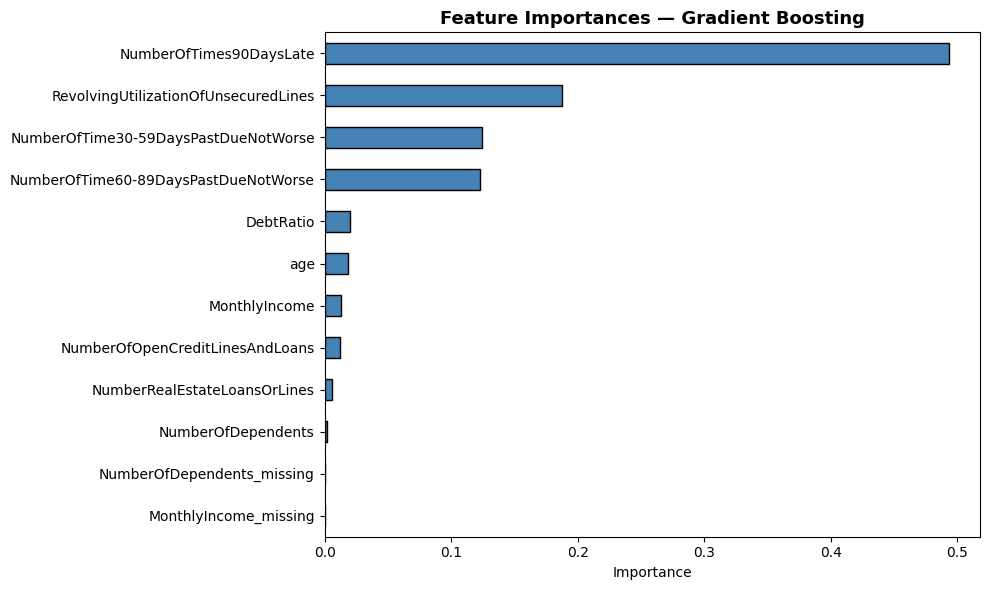

In [22]:
final_model = best_pipe.named_steps['model']

if hasattr(final_model, 'feature_importances_'):
    # Tree-based: use feature_importances_
    importances = final_model.feature_importances_

    # Reconstruct feature names after MissingFlagAdder added columns
    base_features = X_train.columns.tolist()
    flag_features = [c + '_missing' for c in COLS_TO_FLAG]
    all_features = base_features + flag_features

    # Align lengths in case flag columns pushed the count up
    all_features = all_features[:len(importances)]

    feat_imp = pd.Series(importances, index=all_features).sort_values(ascending=True)

    plt.figure(figsize=(10, 6))
    feat_imp.plot(kind='barh', color='steelblue', edgecolor='black')
    plt.title(f'Feature Importances — {best_name}', fontsize=13, fontweight='bold')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

elif hasattr(final_model, 'coef_'):
    # Logistic Regression: use coefficients
    base_features = X_train.columns.tolist()
    flag_features = [c + '_missing' for c in COLS_TO_FLAG]
    all_features = base_features + flag_features
    all_features = all_features[:len(final_model.coef_[0])]

    coefs = pd.Series(final_model.coef_[0], index=all_features).sort_values(ascending=True)

    plt.figure(figsize=(10, 6))
    colors = ['tomato' if c > 0 else 'steelblue' for c in coefs.values]
    coefs.plot(kind='barh', color=colors, edgecolor='black')
    plt.axvline(x=0, color='black', linewidth=0.8)
    plt.title(f'Coefficients — {best_name}', fontsize=13, fontweight='bold')
    plt.xlabel('Coefficient Value')
    plt.tight_layout()
    plt.show()

---
## 11. Pipeline Inspection

A quick look at what the pipeline learned — which columns were capped, which were log-transformed, and what the scaler stored.

In [23]:
print('Pipeline steps:')
for step_name, step_obj in best_pipe.steps:
    print(f'  {step_name}: {type(step_obj).__name__}')

Pipeline steps:
  flag_missing: MissingFlagAdder
  cap_outliers: OutlierCapper
  impute: SimpleImputer
  fix_skewness: SkewnessTransformer
  scale: StandardScaler
  model: GradientBoostingClassifier


In [24]:
# OutlierCapper bounds learned from training data
capper = best_pipe.named_steps['cap_outliers']
bounds = pd.DataFrame({
    'Lower Bound': capper.lower_bounds_,
    'Upper Bound': capper.upper_bounds_
})
print('Outlier caps learned from training data:')
print(bounds.round(4))

Outlier caps learned from training data:
    Lower Bound  Upper Bound
0        0.0000       1.0921
1       24.0000      87.0000
2        0.0000       3.0000
3        0.0000    4933.6900
4        0.0000   25144.6800
5        1.0000      24.0000
6        0.0000       2.0000
7        0.0000       4.0000
8        0.0000       2.0000
9        0.0000       4.0000
10       0.0000       1.0000
11       0.0000       1.0000


In [25]:
# SkewnessTransformer — which columns were log-transformed
skew_transformer = best_pipe.named_steps['fix_skewness']
print('Columns selected for log1p transformation:')
print(skew_transformer.cols_to_transform_)

Columns selected for log1p transformation:
[2, 3, 4, 6, 8, 9, 10, 11]


---
## 12. Predict on New Data

The pipeline is a single object. To predict on any new data, pass it directly to `predict` or `predict_proba`. No separate preprocessing steps needed.

In [26]:
# Example: predict on the first 5 rows of the test set
sample = X_test.iloc[:5]

predictions = best_pipe.predict(sample)
probabilities = best_pipe.predict_proba(sample)[:, 1]

result_df = sample.copy()
result_df['Predicted'] = predictions
result_df['Default Probability'] = probabilities.round(4)
result_df['Actual'] = y_test.iloc[:5].values

print(result_df[['Predicted', 'Default Probability', 'Actual']])

        Predicted  Default Probability  Actual
141877          0               0.0326       0
45126           0               0.0091       0
86776           0               0.0071       0
75627           0               0.0273       0
125977          0               0.0194       0


---
## 13. Save the Best Pipeline

In [ ]:
import joblib

joblib.dump(best_pipe, 'best_pipeline.pkl')
print(f'Pipeline saved as best_pipeline.pkl')
print(f'Model: {best_name}')
print(f'Test AUC: {results[best_name]["test_auc"]:.4f}')

In [ ]:
# Verify it loads and works
loaded_pipe = joblib.load('best_pipeline.pkl')
loaded_auc = roc_auc_score(y_test, loaded_pipe.predict_proba(X_test)[:, 1])
print(f'Loaded pipeline AUC: {loaded_auc:.4f} (should match above)')